In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

df = pd.read_csv("data/credito.csv")

df.head()

X = df.drop(
    columns=[
        "id_contrato",
        "inadimplente"
    ]
)

y = df["inadimplente"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



In [2]:
numericas = X.select_dtypes(
    include=np.number
).columns.tolist()

categoricas = X.select_dtypes(
    exclude=np.number
).columns.tolist()

pipeline_num = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

pipeline_cat = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessador = ColumnTransformer([
    (
        "num",
        pipeline_num,
        numericas
    ),
    (
        "cat",
        pipeline_cat,
        categoricas
    )
])

In [3]:
pipeline = Pipeline([
    (
        "preprocessamento",
        preprocessador
    ),

    (
        "modelo",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [4]:
pipeline.fit(
    X_treino,
    y_treino
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['idade','renda_mensal','tempo_emprego_anos',...,'finalidade', 'prazo_meses','valor_emprestimo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [5]:
probabilidades = pipeline.predict_proba(
    X_teste
)[:,1]

predicoes = (
    probabilidades >= 0.5
).astype(int)

In [6]:
acuracia = accuracy_score(
    y_teste,
    predicoes
)

precisao = precision_score(
    y_teste,
    predicoes
)

recall = recall_score(
    y_teste,
    predicoes
)

f1 = f1_score(
    y_teste,
    predicoes
)

roc_auc = roc_auc_score(
    y_teste,
    probabilidades
)

print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Acurácia: 0.8058
Precisão: 0.5888
Recall: 0.2500
F1 Score: 0.3510
ROC AUC: 0.7625


In [7]:
cm = confusion_matrix(
    y_teste,
    predicoes
)

print(cm)

[[904  44]
 [189  63]]


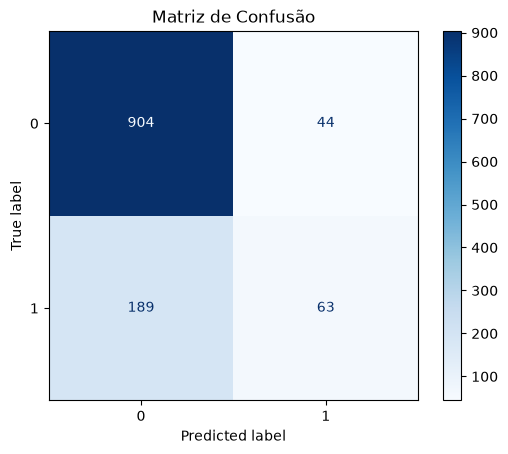

In [8]:
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(
    cmap="Blues"
)

plt.title(
    "Matriz de Confusão"
)

plt.show()

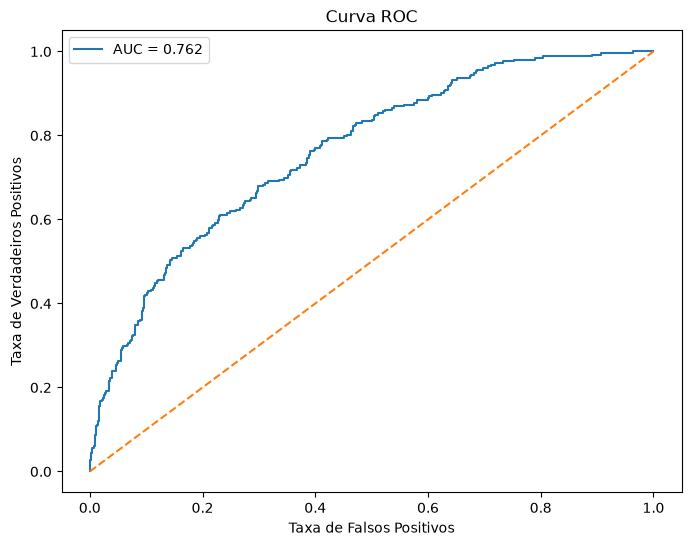

In [9]:
fpr, tpr, _ = roc_curve(
    y_teste,
    probabilidades
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel(
    "Taxa de Falsos Positivos"
)

plt.ylabel(
    "Taxa de Verdadeiros Positivos"
)

plt.title(
    "Curva ROC"
)

plt.legend()

plt.show()

## Conclusão

O modelo de Regressão Logística apresentou acurácia de 80,58% e ROC AUC de 0,7625 no conjunto de teste, demonstrando boa capacidade de distinguir clientes adimplentes e inadimplentes. Apesar da boa acurácia, o recall de 25% indica que parte dos inadimplentes ainda não está sendo identificada pelo modelo. No contexto da fintech, o falso negativo representa o erro mais crítico, pois corresponde à aprovação de um cliente inadimplente, gerando prejuízo financeiro direto. Já o falso positivo representa a recusa de um cliente que pagaria corretamente, causando perda de oportunidade de lucro. Como o custo do falso negativo é significativamente maior, ele deve receber atenção especial na definição do limiar de decisão.